In this task, you need to use a publicly available simple MNIST dataset and build 3 classification
models around it. It should be the following models:
1) Random Forest;
2) Feed-Forward Neural Network;
3) Convolutional Neural Network;

# Hand writen digits Classification


In [1]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split


In [2]:
from mnist_classifier.classifier import MnistClassifier

In [43]:
nn = MnistClassifier(algorithm='nn')


In [4]:
rf = MnistClassifier(algorithm='rf')
cnn = MnistClassifier(algorithm='cnn')
nn = MnistClassifier(algorithm='nn')

In [5]:
def load_mnist_dataset(validation_split=0.1):
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    X_train = (X_train / 255.0).astype(np.float32)
    X_test = (X_test / 255.0).astype(np.float32)
    y_train = y_train.astype(np.int64)
    y_test = y_test.astype(np.int64)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train,
        test_size=validation_split,
        random_state=42,
        stratify=y_train
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [6]:
def plot_learning_curves(history):
    if history is None:
        print("No training history available for plotting.")
        return
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')

    plt.show()

In [7]:
def evaluate_model(y_pred, y_true):
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    class_report = classification_report(y_true, y_pred)

    return accuracy, cm, class_report

## Loading dataset & Exploratory Data analysis

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = load_mnist_dataset()

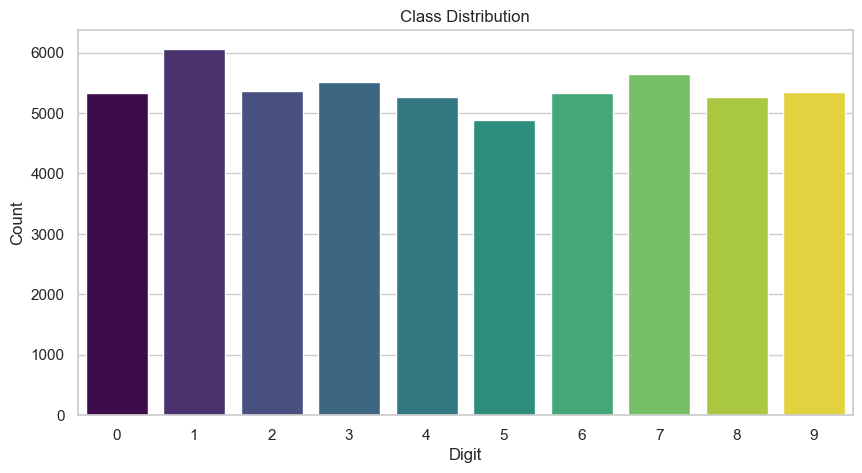

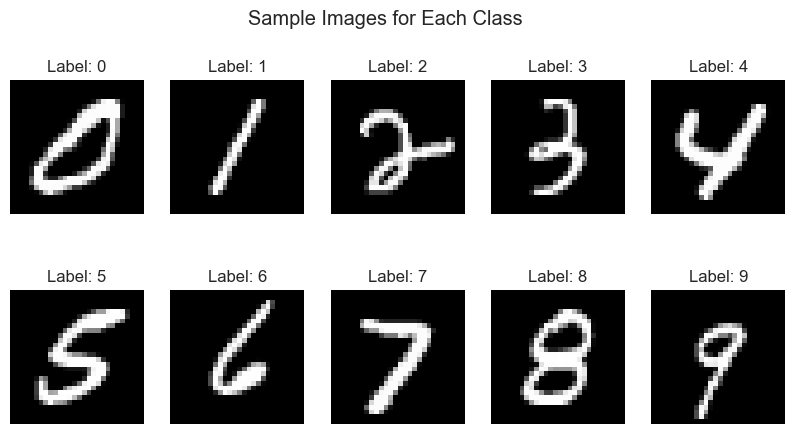

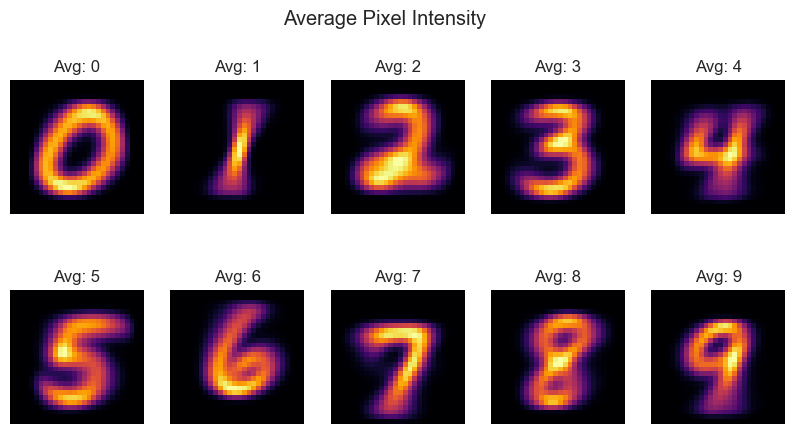


========== Dataset Analysis ==========
Shape: (54000, 28, 28)
Number of images: 54000
Resolution: 28x28
Pixels per image: 784
Total pixels: 42,336,000
------------------------------
Data Type: float32
Min value: 0.0000
Max value: 1.0000
Mean: 0.1307


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')

def plot_class_distribution(y_train):
    plt.figure(figsize=(10, 5))
    sns.countplot(x=y_train, hue=y_train, palette="viridis", legend=False)
    plt.title('Class Distribution')
    plt.xlabel('Digit')
    plt.ylabel('Count')
    plt.show()

def plot_sample_images(x_train, y_train):
    plt.figure(figsize=(10, 5))
    for i in range(10):
        idx = np.where(y_train == i)[0][0]
        image = x_train[idx]

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Label: {i}")
        plt.axis('off')
    plt.suptitle("Sample Images for Each Class")
    plt.show()

def plot_average_digits(x_train, y_train):
    plt.figure(figsize=(10, 5))
    for i in range(10):
        images = x_train[y_train == i]
        avg_img = np.mean(images, axis=0)

        plt.subplot(2, 5, i + 1)
        plt.imshow(avg_img, cmap='inferno')
        plt.title(f"Avg: {i}")
        plt.axis('off')
    plt.suptitle("Average Pixel Intensity")
    plt.show()

def analyze_dataset_properties(name, data):
    print(f"\n{'='*10} Dataset Analysis {'='*10}")

    shape = data.shape
    ndim = data.ndim
    count = shape[0]

    if ndim == 3:
        h, w = shape[1], shape[2]
        pixels_per_image = h * w
        resolution = f"{h}x{w}"
    elif ndim == 4:
        h, w, c = shape[1], shape[2], shape[3]
        pixels_per_image = h * w * c
        resolution = f"{h}x{w} (Channels: {c})"
    elif ndim == 2:
        pixels_per_image = shape[1]
        resolution = f"Flattened vector (len={shape[1]})"
    else:
        pixels_per_image = "Unknown structure"
        resolution = "Unknown"

    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()

    dtype = data.dtype
    print(f"Shape: {shape}")
    print(f"Number of images: {count}")
    print(f"Resolution: {resolution}")
    print(f"Pixels per image: {pixels_per_image}")
    print(f"Total pixels: {data.size:,}")
    print("-" * 30)
    print(f"Data Type: {dtype}")
    print(f"Min value: {min_val:.4f}")
    print(f"Max value: {max_val:.4f}")
    print(f"Mean: {mean_val:.4f}")

    print("="*45)

plot_class_distribution(y_train)
plot_sample_images(X_train, y_train)
plot_average_digits(X_train, y_train)
analyze_dataset_properties("mnist", X_train)

## Neural Network

In [44]:
history = nn.train(X_train, y_train, X_val, y_val)

Training NN model...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 978us/step - accuracy: 0.9212 - loss: 0.2733 - val_accuracy: 0.9558 - val_loss: 0.1605
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 915us/step - accuracy: 0.9647 - loss: 0.1202 - val_accuracy: 0.9665 - val_loss: 0.1187
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 938us/step - accuracy: 0.9755 - loss: 0.0815 - val_accuracy: 0.9702 - val_loss: 0.1068
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 936us/step - accuracy: 0.9811 - loss: 0.0623 - val_accuracy: 0.9700 - val_loss: 0.1012
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 909us/step - accuracy: 0.9857 - loss: 0.0476 - val_accuracy: 0.9733 - val_loss: 0.0990
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 918us/step - accuracy: 0.9884 - loss: 0.0371 - val_accuracy: 0.9770 - val_loss: 0.0878
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 905us/step - accuracy: 0.9906 - loss: 0.0305 - val_accuracy: 0.9728 - val_loss: 0.0944
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step

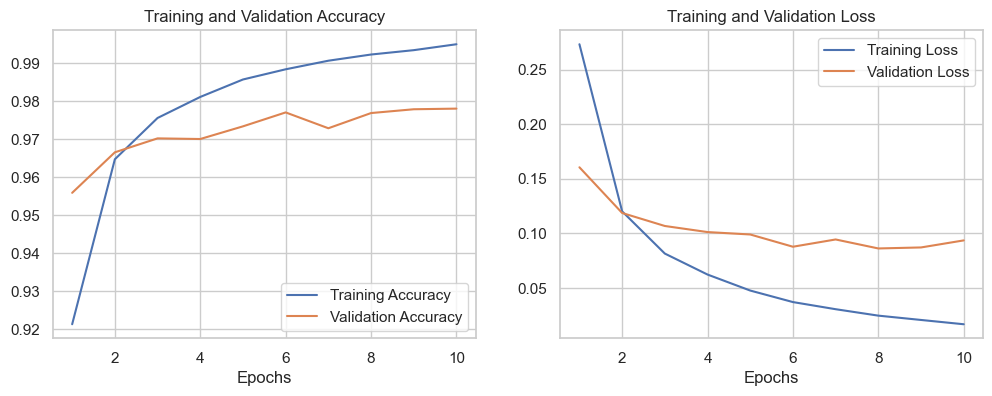

In [45]:
plot_learning_curves(history)

Observation: Early-stage overfitting. The model demonstrates high variance, where training performance significantly outpaces validation metrics after the 4th epoch. The flattening of the validation accuracy at approximately 97.5% suggests the model is trapped in a local optimum. In a production environment, this would be the ideal point for Early Stopping to preserve the best generalization state found at epoch 6.

In [12]:
y_pred_nn = nn.predict(X_test)

Test accuracy for Neural Network (NN): 0.9773


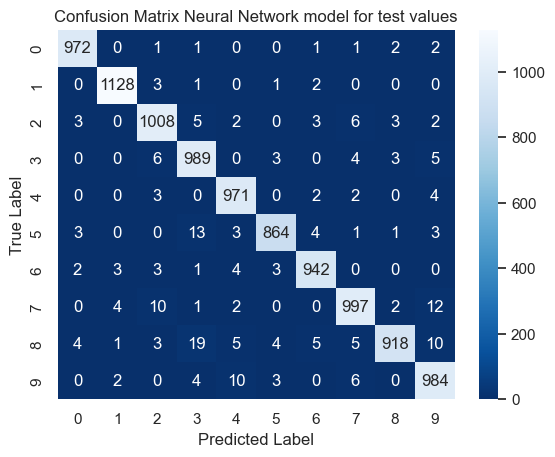

Classification Report for Neural Network:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [13]:
accuracy_nn, cm_nn, class_report_nn = evaluate_model(y_pred_nn, y_test)
print(f'Test accuracy for Neural Network (NN): {accuracy_nn:.4f}')
print('='*99)
labels = range(0, 10)
heatmap = sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues_r',xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Neural Network model for test values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print('='*99)
print('Classification Report for Neural Network: ', class_report_nn)


In [14]:
print('Classification Report for Neural Network: ', class_report_nn)

Classification Report for Neural Network:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## CNN

In [15]:
history = cnn.train(X_train, y_train, X_val, y_val)

Training CNN model...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9270 - loss: 0.2322 - val_accuracy: 0.9830 - val_loss: 0.0616
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9715 - loss: 0.0894 - val_accuracy: 0.9870 - val_loss: 0.0498
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9771 - loss: 0.0715 - val_accuracy: 0.9870 - val_loss: 0.0429
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9806 - loss: 0.0606 - val_accuracy: 0.9887 - val_loss: 0.0391
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9830 - loss: 0.0542 - val_accuracy: 0.9882 - val_loss: 0.0375
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9844 - loss: 0.0499 - val_accuracy: 0.9870 - val_loss: 0.0448
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9855 - loss: 0.0441 - val_accuracy: 0.9892 - val_loss: 0.0365
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - ac

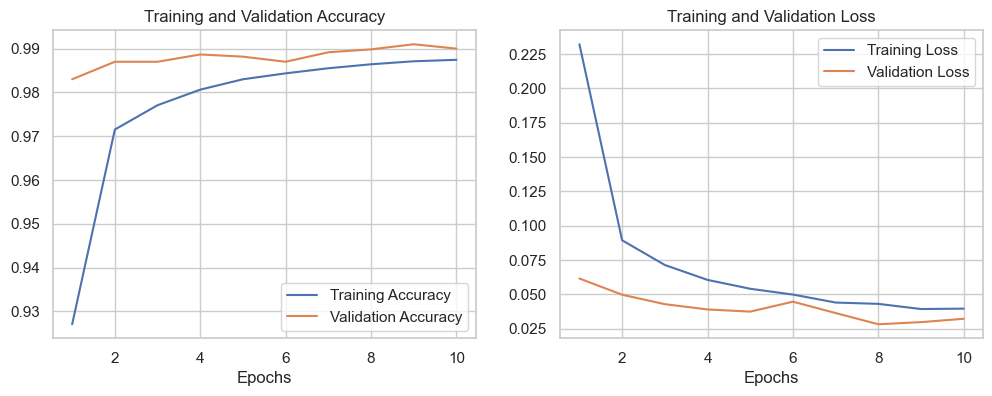

In [16]:
plot_learning_curves(history)

The learning curves demonstrate strong convergence. The model achieves high accuracy within the first few epochs. The validation loss remains low and stable, indicating that the model generalizes well and is not overfitting.

Note: Validation accuracy is consistently higher than training accuracy. This is expected behavior when using Dropout, as regularization is active during training (reducing performance) but deactivated during validation

In [17]:
y_pred_rf = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Test accuracy for Convolutional Neural Network (CNN): 0.9707


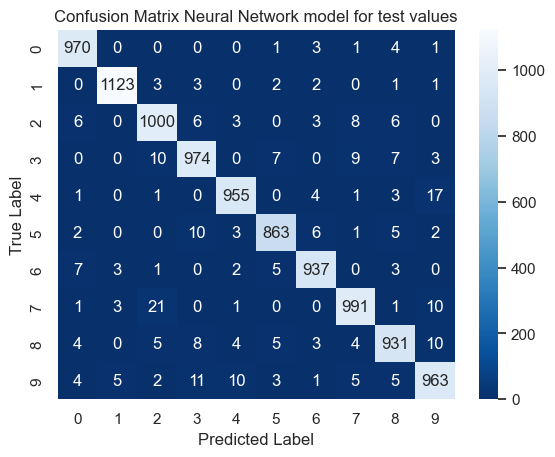

Classification Report for Neural Network:                precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [46]:
accuracy_rf, cm_cnn, class_report_rf = evaluate_model(y_pred_rf, y_test)
print(f'Test accuracy for Convolutional Neural Network (CNN): {accuracy_rf:.4f}')
print('='*99)
labels = range(0, 10)
heatmap = sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues_r',xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Neural Network model for test values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print('='*99)
print('Classification Report for Neural Network: ', class_report_rf)

# Random Forest

In [19]:
history = rf.train(X_train, y_train, X_val, y_val)

Training RF model...
Training complete


In [20]:
y_pred_rf = rf.predict(X_test)

Test accuracy for Random Forest: 0.9707


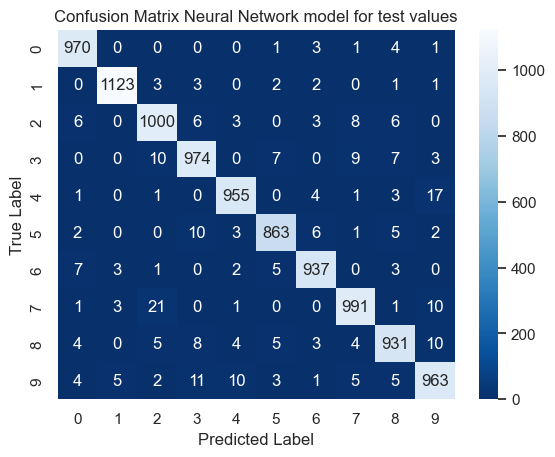

Classification Report for Neural Network:                precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [47]:
accuracy_rf, cm_rf, class_report_rf = evaluate_model(y_pred_rf, y_test)
print(f'Test accuracy for Random Forest: {accuracy_rf:.4f}')
print('='*99)
labels = range(0, 10)
heatmap = sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues_r',xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Neural Network model for test values')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print('='*99)
print('Classification Report for Neural Network: ', class_report_rf)

While CNN provides the highest accuracy by capturing spatial hierarchies, Random Forest offers the most stable and computationally efficient alternative for baseline classification. The Feed-Forward NN serves as a middle ground but requires heavy regularization to match the generalization capabilities of the other two architectures.